# ML Uppgift 1 Housing Project
## Spår A - Regression  (förutsäga bostadsvärde)

In [60]:
import sys
print(sys.version)

3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.decomposition import PCA  

In [62]:
df = pd.read_csv("housing.csv")
print("shape:", df.shape)
df.head()

shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Data & EDA (kort data-insikt)

I detta avsnitt analyseras datasetets struktur, datatyper och saknade värden.
Syftet är att skapa en grundläggande förståelse för datan inför modellering.

### Datasetets storlek

Datasetet har 20 640 rader och 10 kolumner. Det är tillräckligt med data för att träna modellen.

### Datatyper

In [63]:
display(df.dtypes)
print("\nKolumner:")
print(list(df.columns))

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


Kolumner:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [65]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


De numeriska variablerna varierar i skala och spridning, vilket motiverar användning av standardisering i modelleringen.

### Saknade värden

Det finns saknade värden i total_bedrooms.
Dessa fylls i med medianvärdet eftersom det är mer stabilt än medelvärde.

In [66]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Det finns 207 saknade värden i kolumnen `total_bedrooms`.
Övriga variabler saknar saknade värden.
Dessa kommer att hanteras i pipelinen med imputering (medianvärde).

### Fördelning av target-variabeln

Nedan visas fördelningen av `median_house_value`.

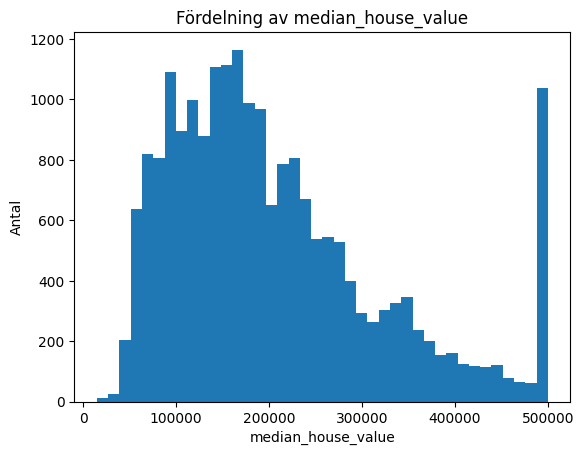

In [67]:
fig, ax = plt.subplots()

ax.hist(df["median_house_value"], bins=40)
ax.set_title("Fördelning av median_house_value")
ax.set_xlabel("median_house_value")
ax.set_ylabel("Antal")

plt.show()

### Geografisk spridning

Nedan visas hur observationerna är fördelade geografiskt med longitude och latitude.

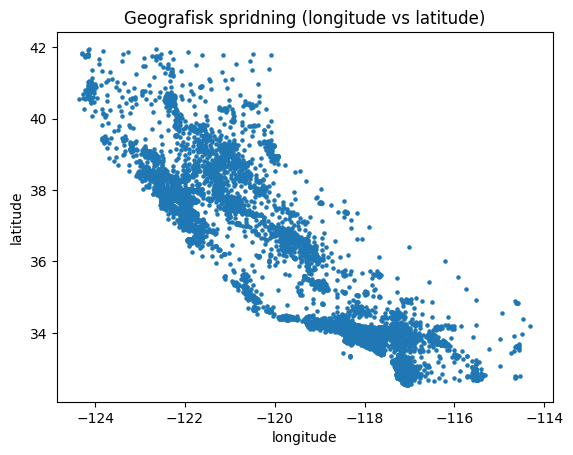

In [68]:
fig, ax = plt.subplots()

ax.scatter(df["longitude"], df["latitude"], s=5)
ax.set_title("Geografisk spridning (longitude vs latitude)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

plt.show()

- Fördelningen av `median_house_value` visar en viss högerskevhet.
- Observationerna är geografiskt koncentrerade i vissa områden, särskilt längs Kaliforniens kust.
- Detta tyder på att geografisk position kan vara en relevant faktor vid   modellering av bostadsvärde.

Target-variabeln som ska förutsägas är `median_house_value`.

In [69]:
target = "median_house_value"

y = df[target].copy()
X = df.drop(columns=[target]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 9)
y shape: (20640,)


### Train/Test-split

Datan delas upp i träningsdata (80%) och testdata (20%).
Testdatan används endast för slutlig utvärdering.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 9)
X_test: (4128, 9)


### Preprocessing (utan leakage)

Preprocessing görs i en pipeline så att ingen information från testdatan påverkar träningen.
Numeriska variabler skalas och saknade värden imputeras.
Kategoriska variabler one-hot-encodas.

In [71]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeriska kolumner:", num_cols)
print("Kategoriska kolumner:", cat_cols)

Numeriska kolumner: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Kategoriska kolumner: ['ocean_proximity']


In [72]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

### Modelljämförelse (baseline + 2 modeller)

Tre modeller jämförs:

- DummyRegressor som baseline.
- Ridge (linjär modell med regularisering).
- RandomForestRegressor (icke-linjär modell).

Utvärdering sker med 5-fold cross-validation och MAE.

In [73]:
models = {
    "Baseline (Dummy)": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=SEED)
}

In [74]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mae_mean = -scores.mean()
    mae_std = scores.std()

    results.append((name, mae_mean, mae_std))

cv_results = (
    pd.DataFrame(results, columns=["Model", "CV_MAE_Mean", "CV_MAE_Std"])
      .sort_values("CV_MAE_Mean")
)

cv_results

,Model,CV_MAE_Mean,CV_MAE_Std
2,RandomForest,32206.386933,523.774114
1,Ridge,49665.128165,779.278569
0,Baseline (Dummy),91394.674508,848.160631


### Modellval

Resultaten från cross-validation visar att RandomForest hade lägst genomsnittlig MAE jämfört med både baseline-modellen (DummyRegressor) och Ridge.

Detta innebär att RandomForest ger mer träffsäkra prediktioner och därför väljs som slutmodell för vidare optimering.

### Robusthet i resultaten

Cross-validation användes för att utvärdera modellerna på flera olika delar av träningsdatan.

Det gör resultaten mer stabila och minskar risken att modellens prestanda beror på en specifik uppdelning av data. Att RandomForest presterar bäst över flera foldar tyder på att modellen är robust.

### Hyperparameter-tuning (RandomForest)

RandomForest valdes eftersom den hade lägst MAE i cross-validation.
Modellen optimeras med GridSearchCV och utvärderas med MAE.

In [75]:

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_mae_cv = -grid.best_score_
best_params = grid.best_params_

print(f"Best MAE (CV): {best_mae_cv:.2f}")
print("Best parameters:", best_params)

Best MAE (CV): 32122.17
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


### Slutlig utvärdering på testdata

Den optimerade modellen utvärderas på testdatan.
MAE och RMSE rapporteras.

In [76]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5  

print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Test MAE: 31465.25
Test RMSE: 48781.91


## Viktigaste variabler (feature importance)

För att förstå vilka variabler som påverkar modellens prediktioner mest analyseras feature importance från den optimerade RandomForest-modellen.

In [77]:
rf_model = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
)

feat_imp.head(10)

num__median_income                 0.490384
cat__ocean_proximity_INLAND        0.141366
num__longitude                     0.105698
num__latitude                      0.101170
num__housing_median_age            0.052319
num__population                    0.032625
num__total_rooms                   0.023652
num__total_bedrooms                0.023641
num__households                    0.018241
cat__ocean_proximity_NEAR OCEAN    0.006415
dtype: float64

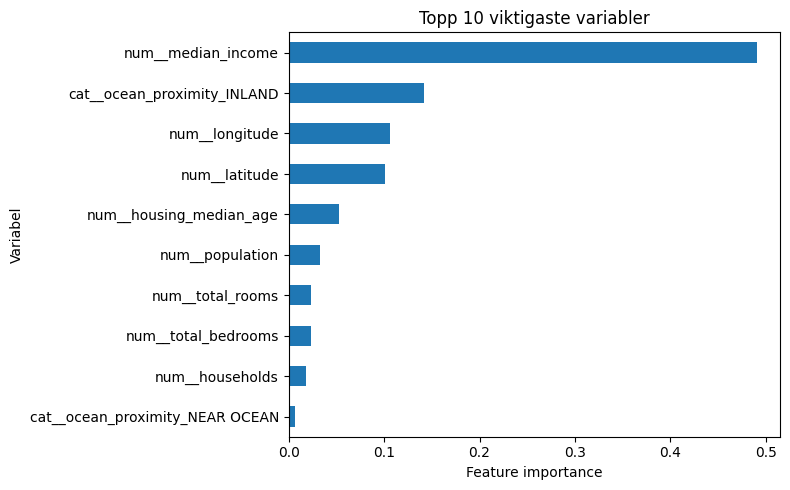

In [78]:
top_n = 10
top_features = feat_imp.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
top_features.plot(kind="barh", ax=ax)

ax.set_title("Topp 10 viktigaste variabler")
ax.set_xlabel("Feature importance")
ax.set_ylabel("Variabel")

plt.tight_layout()
plt.show()

### Tolkning

De viktigaste variablerna har störst påverkan på modellens prediktioner.

Om exempelvis median_income ligger högt tyder det på att områdets inkomstnivå är en stark faktor för bostadsvärde. Även geografiska variabler kan vara viktiga, vilket är rimligt eftersom läge påverkar priser.

Detta ger en bättre förståelse för hur modellen fattar sina beslut.

### PCA-analys

PCA används för att undersöka om de numeriska variablerna kan sammanfattas
i färre dimensioner.

Analysen görs endast på numeriska variabler och efter standardisering.

In [79]:
X_num = X[num_cols].copy()

imputer = SimpleImputer(strategy="median")
X_num_imputed = imputer.fit_transform(X_num)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_imputed)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("Förklarad varians per komponent:")
print(pca.explained_variance_ratio_)

Förklarad varians per komponent:
[0.48755031 0.2384736 ]


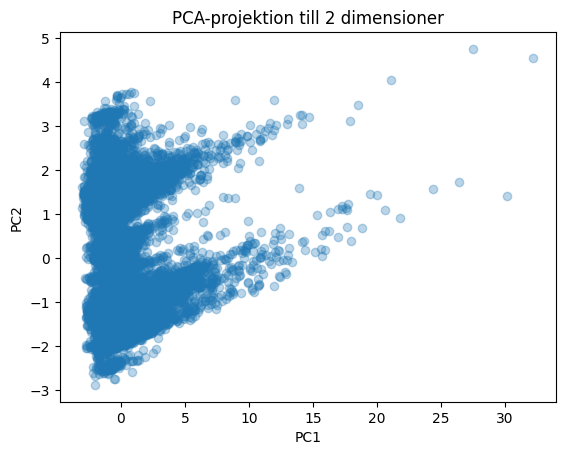

In [80]:
fig, ax = plt.subplots()
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA-projektion till 2 dimensioner")
plt.show()

### Tolkning av PCA

De två första huvudkomponenterna förklarar cirka 72 % av variationen i de numeriska variablerna.

Detta innebär att en stor del av informationen i datan kan sammanfattas 
i två dimensioner, men inte all variation fångas.

Spridningen i figuren visar att datan har viss struktur och klusterliknande 
mönster, vilket kan indikera att vissa områden eller bostadstyper skiljer sig 
åt.

Osäkerhet:
- PCA fångar endast linjära samband.
- Tolkningen av komponenterna är inte direkt intuitiv.
- Informationsförlust sker när dimensionerna reduceras.

### Slutsats

Målet med projektet var att förutsäga bostadsvärdet (`median_house_value`)
med hjälp av variabler i datasetet.

Efter att ha jämfört flera modeller presterade RandomForest bäst.
Efter optimering fick modellen en test-MAE på cirka 31 000 och en
RMSE på cirka 48 800.

Detta visar att modellen kan göra rimliga prediktioner, men att det
fortfarande finns felmarginaler.

PCA-analysen visade att de två första komponenterna förklarar cirka
72 % av variationen i de numeriska variablerna. Det betyder att mycket
av informationen kan sammanfattas i färre dimensioner, men inte all.

Sammanfattningsvis fungerar modellen bra, men resultaten påverkas av
val av parametrar och hur datan är uppbyggd.

### Begränsningar

- Datasetet innehåller områdesdata och inte information om enskilda bostäder.
- Modellen påverkas av hur saknade värden hanteras.
- RandomForest är mindre tolkbar än en linjär modell.
- Resultaten kan variera beroende på val av parametrar och random seed.
- PCA fångar endast linjära samband och innebär viss informationsförlust.